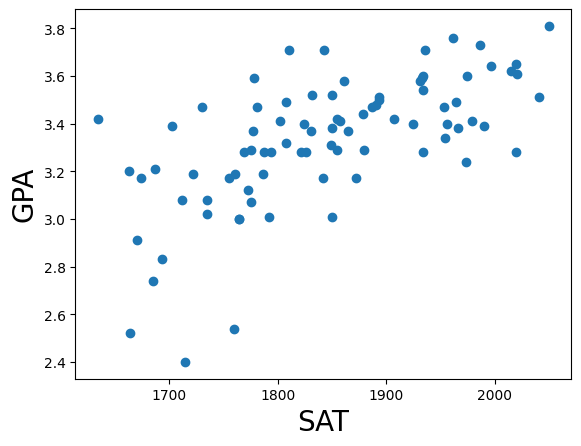

84
3.3925000000000005  |  3.51
3.2749999999999995  |  3.52
3.2949999999999995  |  3.52
3.3975000000000004  |  3.54
3.295  |  3.58
3.3974999999999995  |  3.58
3.3975000000000004  |  3.59
3.2587500000000005  |  3.59
3.3899999999999997  |  3.6
3.3975000000000004  |  3.6
3.3874999999999993  |  3.61
3.3874999999999993  |  3.62
3.3662499999999995  |  3.64
3.3874999999999993  |  3.65
3.2950000000000004  |  3.71
3.3975000000000004  |  3.71
3.30875  |  3.71
3.3662500000000004  |  3.73
3.37625  |  3.76
3.3874999999999993  |  3.81
MSE 0.08137789062500003
MAE 0.2711875000000001


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Change to data path on your computer
data = \
pd.read_csv("C:/Users/PC/OneDrive/Desktop/Học máy/23000104_Nguyễn Hữu Dũng_Knn_linearRegression/SAT_GPA (1).csv")
# Show the description of data
data.describe()
# Set to training data (x, y)
y = data['GPA']
x = data['SAT']
# Remind that we need to put component x_0 = 1 to x
plt.scatter(x,y)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()
k = 8
def distance(array, value):
  array = np.array(array)
  return abs(array - value)
def find_nearest_index(array, value, k):
  array_D = distance(array, value)
  return np.argsort(array_D)[:k]
data_len = len(x)
print(data_len)
X_train = np.array(x[:64])
Y_train = np.array(y[:64])
X_test = np.array(x[64:data_len])
Y_test = np.array(y[64:data_len])
k = 8

Y_pred = np.zeros(len(X_test))
mse_check  = 0
mae_check  = 0
R_squared = 0

for i in range(len(X_test)):
  indexis = find_nearest_index(X_train, X_test[i], k)
  for id in indexis:
      Y_pred[i] = Y_pred[i] + Y_train[id]
  Y_pred[i] = Y_pred[i]/len(indexis)
  print(Y_pred[i], ' | ', Y_test[i])
  mean_train = np.mean(Y_pred)

  mse_check = mse_check + (Y_pred[i] - Y_test[i])**2
  mae_check = mae_check + abs(Y_pred[i] - Y_test[i])
print('MSE', mse_check/len(X_test))
print('MAE', mae_check/len(X_test))

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print('MSE:', mean_squared_error(Y_test, Y_pred))
print('MAE:', mean_absolute_error(Y_test, Y_pred))
print('R-Square:', r2_score(Y_test, Y_pred))

MSE: 0.08137789062500003
MAE: 0.2711875000000001
R-Square: -10.951518670142466


In [8]:
def knn_predict(X_train, Y_train, X_test,k):
  Y_pred = np.zeros(len(X_test))
  for i, X_test in enumerate(X_test):
    indexis = find_nearest_index(X_train, X_test[i], k)
    Y_pred[i] = np.mean(Y_train[indexis])
  return Y_pred

Ví dụ A2

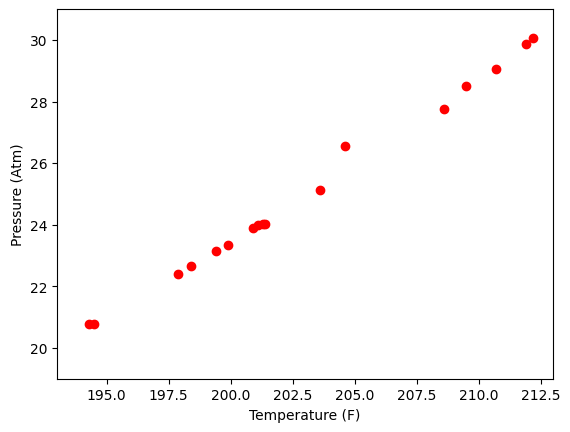

In [12]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

#Temp (F degree)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6, 204.6,  209.5, 208.6, 210.7, 211.9, 212.2]]).T

#Press (Atm)
Y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57, 28.49, 27.76, 29.04, 29.88, 30.06]]).T

plt.plot(X, Y, 'ro')
plt.axis([193, 213, 19, 31])
plt.xlabel("Temperature (F)")
plt.ylabel("Pressure (Atm)")
plt.show()

In [13]:
k = 4
def distance(array, value):
    array = np.array(array)
    return abs(array - value)

def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

dat_len = len(X)
X_train = np.array(X[:16])
Y_train = np.array(Y[:16])

X_test = np.array(X[16:dat_len])
Y_test = np.array(Y[16:dat_len])
#np.linalg.norm(n - v, 2)

In [14]:
def knn_predict(X_train, Y_train, X_test, k):
    Y_pred = np.zeros(len(X_test))
    for i, x_test in enumerate(X_test):
        # Tìm k hàng xóm gần nhất
        indices = find_nearest_index(X_train, x_test, k)
        # Lấy trung bình Y_train của k hàng xóm
        Y_pred[i] = np.mean(Y_train[indices])
    return Y_pred

In [15]:
Y_pred = knn_predict(X_train, Y_train, X_test, k)
Y_pred

array([20.79])

In [16]:
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Y_test:", Y_test.flatten())
print("Y_pred:", Y_pred)
print("MSE:", mse)
print("MAE:", mae)
print("R-Square:", r2)

Y_test: [30.06]
Y_pred: [20.79]
MSE: 85.93289999999999
MAE: 9.27
R-Square: nan


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Ví Dụ 3A

In [17]:
import math
import numpy as np

In [20]:
with open('fuel.txt') as f:
    lines = f.readlines()

x_data = []
y_data = []
lines.pop(0)

for line in lines:
    splitted = line.replace('\n', '').split(',')
    splitted.pop(0)
    splitted = list(map(float, splitted))
    fuel = 1000 * splitted[1] / splitted[5]
    dlic = 1000 * splitted[0] / splitted[5]
    logMiles = math.log2(splitted[3])
    y_data.append([fuel])
    x_data.append([splitted[-1], dlic, splitted[2], logMiles])

x_data = np.asarray(x_data)
y_data = np.asanyarray(y_data)
x_data

array([[1.80000000e+01, 1.03138007e+03, 2.34710000e+04, 1.65271104e+01],
       [8.00000000e+00, 1.03164106e+03, 3.00640000e+04, 1.37342862e+01],
       [1.80000000e+01, 9.08597153e+02, 2.55780000e+04, 1.57535563e+01],
       [2.17000000e+01, 9.46570576e+02, 2.22570000e+04, 1.65824360e+01],
       [1.80000000e+01, 8.44703336e+02, 3.22750000e+04, 1.73647075e+01],
       [2.20000000e+01, 9.89606180e+02, 3.29490000e+04, 1.63895977e+01],
       [2.50000000e+01, 9.99593430e+02, 4.06400000e+04, 1.43519054e+01],
       [2.30000000e+01, 9.24344838e+02, 3.12550000e+04, 1.25053154e+01],
       [2.00000000e+01, 7.00195273e+02, 3.73830000e+04, 1.05830828e+01],
       [1.36000000e+01, 1.00012416e+03, 2.81450000e+04, 1.68398312e+01],
       [7.50000000e+00, 9.33302595e+02, 2.79400000e+04, 1.68179580e+01],
       [1.60000000e+01, 8.29997134e+02, 2.82210000e+04, 1.20627208e+01],
       [2.50000000e+01, 9.25193414e+02, 2.41800000e+04, 1.54990361e+01],
       [1.90000000e+01, 8.19436731e+02, 3.22590000e

In [21]:
data_length = len(x_data)
X_train = np.array(x_data[:40])
Y_train = np.array(y_data[:40])

X_test = np.array(x_data[40:data_length])
Y_test = np.array(y_data[40:data_length])
X_train

array([[1.80000000e+01, 1.03138007e+03, 2.34710000e+04, 1.65271104e+01],
       [8.00000000e+00, 1.03164106e+03, 3.00640000e+04, 1.37342862e+01],
       [1.80000000e+01, 9.08597153e+02, 2.55780000e+04, 1.57535563e+01],
       [2.17000000e+01, 9.46570576e+02, 2.22570000e+04, 1.65824360e+01],
       [1.80000000e+01, 8.44703336e+02, 3.22750000e+04, 1.73647075e+01],
       [2.20000000e+01, 9.89606180e+02, 3.29490000e+04, 1.63895977e+01],
       [2.50000000e+01, 9.99593430e+02, 4.06400000e+04, 1.43519054e+01],
       [2.30000000e+01, 9.24344838e+02, 3.12550000e+04, 1.25053154e+01],
       [2.00000000e+01, 7.00195273e+02, 3.73830000e+04, 1.05830828e+01],
       [1.36000000e+01, 1.00012416e+03, 2.81450000e+04, 1.68398312e+01],
       [7.50000000e+00, 9.33302595e+02, 2.79400000e+04, 1.68179580e+01],
       [1.60000000e+01, 8.29997134e+02, 2.82210000e+04, 1.20627208e+01],
       [2.50000000e+01, 9.25193414e+02, 2.41800000e+04, 1.54990361e+01],
       [1.90000000e+01, 8.19436731e+02, 3.22590000e

In [22]:
k = 4

def distance(array, value):
    array = np.array(array)
    return np.linalg.norm(array - value, ord=2, axis=1)


def find_nearest_index(array, value, k):
    array_D = distance(array, value)
    return np.argsort(array_D)[:k]

In [23]:
Y_pred = np.zeros(len(X_test))

for i in range(len(X_test)):
    indexis = find_nearest_index(X_train, X_test[i], k)
    for id in indexis:
        Y_pred[i] = Y_pred[i] + Y_train[id]
    Y_pred[i] = Y_pred[i]/len(indexis)
    print(Y_pred[i], ' | ', Y_test[i])

652.8546313611055  |  [711.73305769]
629.7764438184946  |  [697.05277706]
629.7764438184945  |  [638.23106095]
638.961615659754  |  [681.10013659]
658.8735491111272  |  [591.49994589]
662.0865068886196  |  [691.02271186]
610.0186827053449  |  [681.03112144]
599.7734001865958  |  [576.06974956]
662.9799139369711  |  [562.4109333]
535.2791544638845  |  [581.79371695]
662.0865068886196  |  [842.79175243]


C:\Users\PC\AppData\Local\Temp\ipykernel_29400\2425930744.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_pred[i] = Y_pred[i] + Y_train[id]


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print('MSE: ', mean_squared_error(Y_test, Y_pred))
print('MAE: ', mean_absolute_error(Y_test, Y_pred))
print('R-Square: ', r2_score(Y_test, Y_pred))

MSE:  5977.559602693981
MAE:  63.23296216814381
R-Square:  0.02094380947359953


Ví Dụ B1

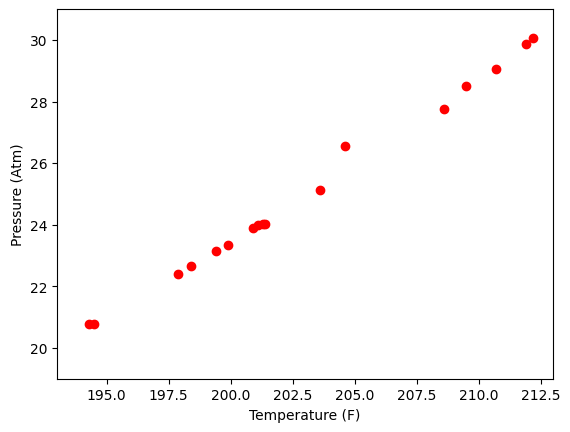

In [25]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

#Temp (F degree)
X = np.array([[194.5, 194.3, 197.9, 198.4, 199.4, 199.9, 200.9, 201.1, 201.4, 201.3, 203.6, 204.6,  209.5, 208.6, 210.7, 211.9, 212.2]]).T

#Press (Atm)
Y = np.array([[20.79, 20.79, 22.4, 22.67, 23.15, 23.35, 23.89, 23.99, 24.02, 24.01, 25.14, 26.57, 28.49, 27.76, 29.04, 29.88, 30.06]]).T

plt.plot(X, Y, 'ro')
plt.axis([193, 213, 19, 31])
plt.xlabel("Temperature (F)")
plt.ylabel("Pressure (Atm)")
plt.show()

In [26]:
#Building Xbar
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis=1)

#Calculate weights of the fitting line
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, Y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)

w =  [[-81.06372713]
 [  0.5228924 ]]


In [27]:
#Preparing the fitting line
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(193, 213, 2)
y0 = w_0 + w_1*x0

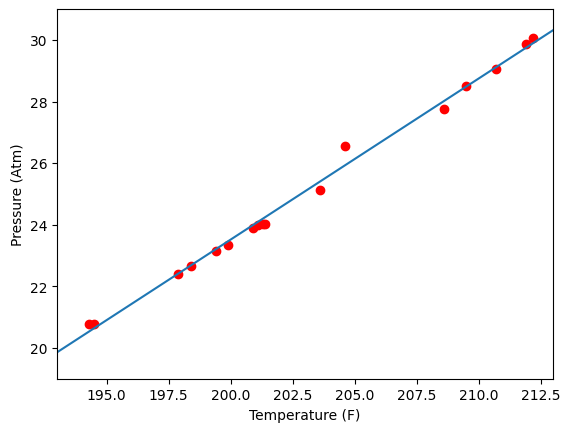

In [28]:
#Drawing the fitting line
plt.plot(X.T, Y.T, 'ro')
plt.plot(x0, y0)
plt.axis([193, 213, 19, 31])
plt.xlabel('Temperature (F)')
plt.ylabel('Pressure (Atm)')
plt.show()